# (01) poisson + BALLS16: (16, 16.0)

project = ```iP-VAE```, host = ```yoru```, device = ```cuda:0```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## Trainer

In [3]:
model_type = 'poisson'
npix = 16
cfg_vae, cfg_tr = default_configs(model_type, f'BALLS{npix}')

cfg_vae['n_latents'] = int(npix * 2)

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 16.0

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |   8.5 K    |
|     ———     |    ———     |
|    layer    |   8.5 K    |
+-------------+------------+

poisson_BALLS16_t-16_z-[32]_u-10,du-10_<grad|lin>
b400-ep1000-lr(0.0005)_beta(16:0.1)_temp(0.01:0.5)_gr(5000)_(2025_03_05,21:43)

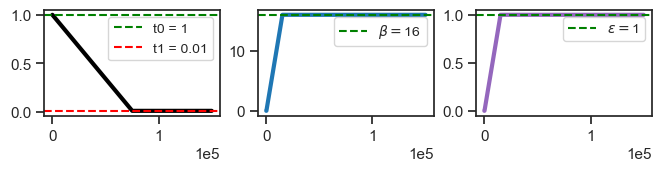

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
tr.n_iters

150000

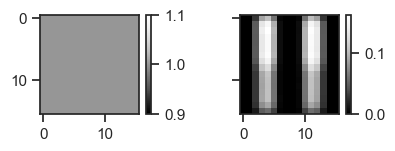

In [6]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

In [7]:
print(tr.model.layer)

PoissonLayer(input_dim=256, latent_dim=32, temperature=1, beta_inner=1, eps=1)

In [8]:
# tr.model.layer.update_n_exp(18.5)
print(tr.model.layer.n_exp)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:0', dtype=torch.int32)

In [9]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([1.], device='cuda:0', grad_fn=<ExpBackward0>),)

In [10]:
# cm = ''
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 1000, avg loss: -404.264: 100%|███| 1000/1000 [1:36:18<00:00,  5.78s/it]


In [11]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0569], device='cuda:0', grad_fn=<ExpBackward0>),)

In [12]:
print(tr.model.layer.n_exp)

tensor([116, 124, 129, 135, 147, 158, 166, 171, 175, 177, 178, 179, 179, 180,
        180, 181], device='cuda:0', dtype=torch.int32)

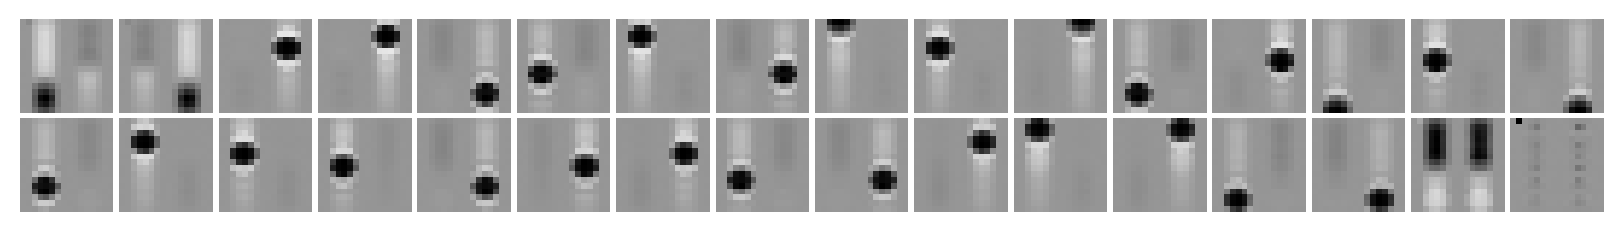

In [16]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), nrows=2, method='abs-max');

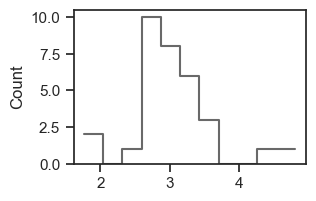

In [17]:
histplot(u0, color='dimgrey')
plt.show()

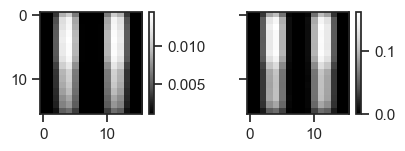

In [18]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 5/5 [00:09<00:00,  1.84s/it]


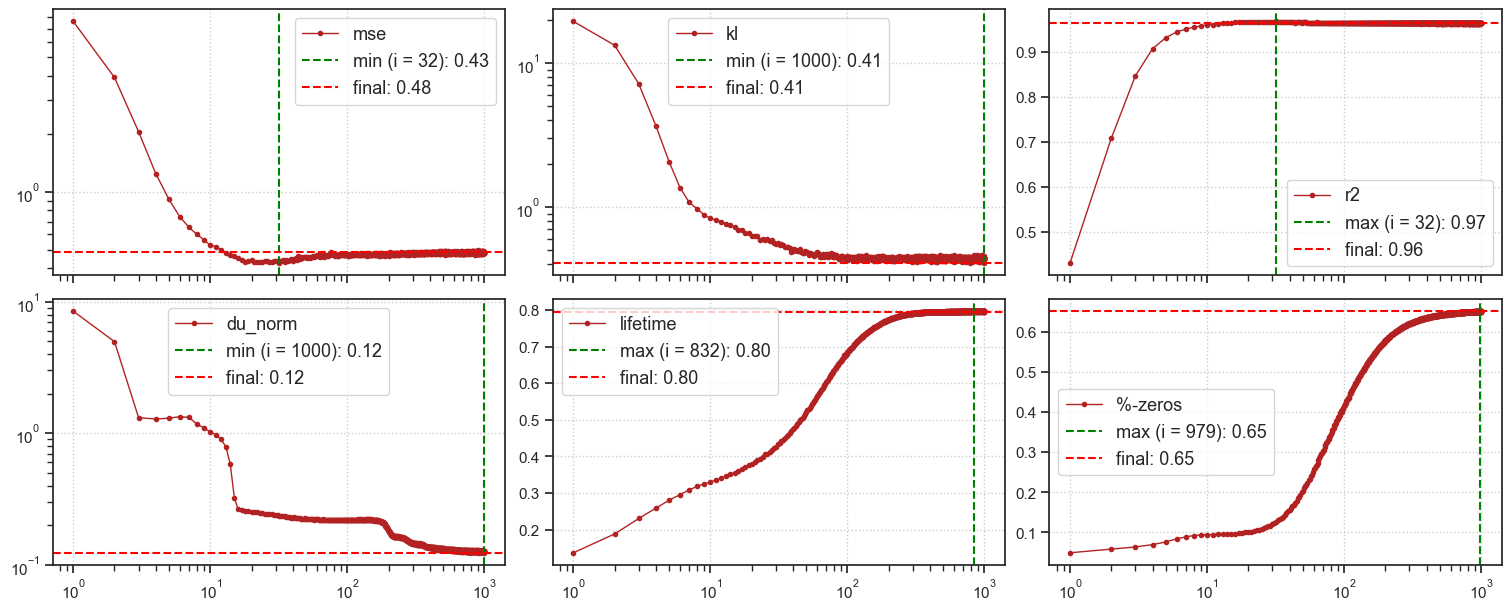

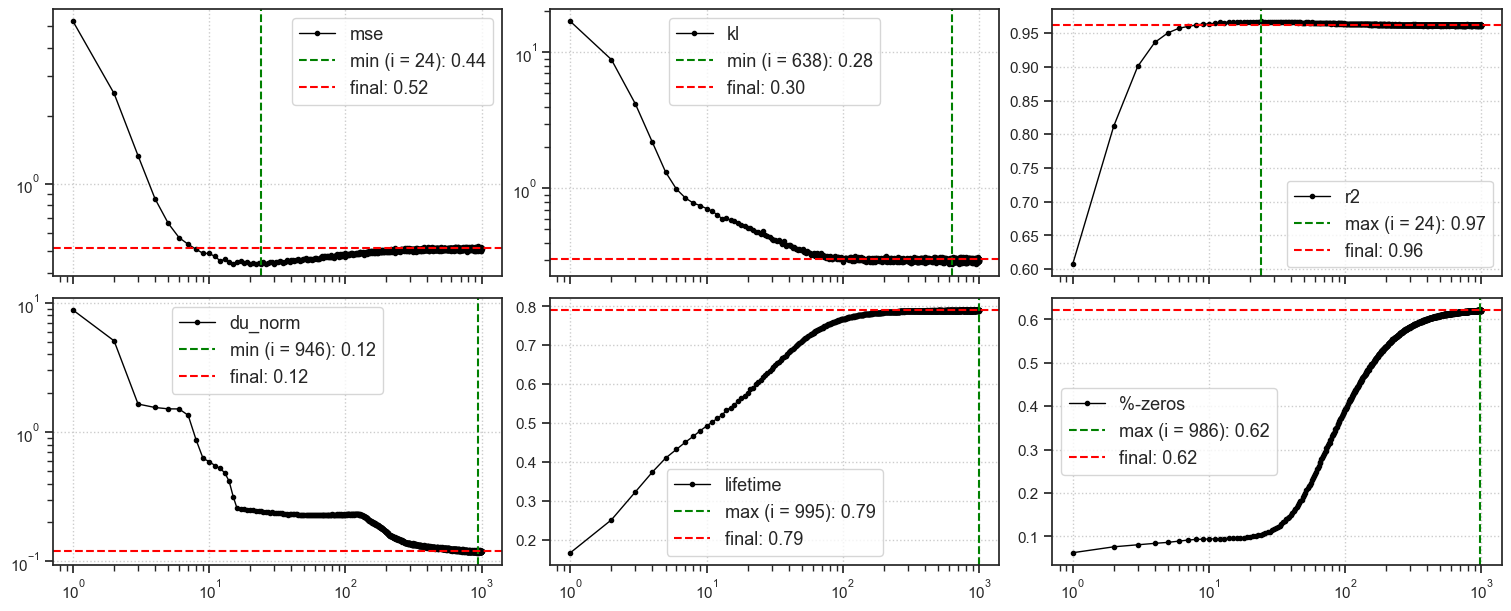

CPU times: user 21.1 s, sys: 244 ms, total: 21.3 s
Wall time: 21.3 s


In [19]:
%%time

kws = dict(
    seq_total=1000,
    seq_batch_sz=1000,
    n_data_batches=5,
)
results = {
    k: tr.analysis(k, **kws)
    for k in ['tst', 'vld']
}
# plot
_ = plot_convergence(results['tst'], color='firebrick')
_ = plot_convergence(results['vld'], color='k')

In [20]:
from analysis.linreg import untangle_score

output = untangle_score(tr, seq_total=1000, seq_batch_sz=100)

100%|███████████████████████████████| 125/125 [03:42<00:00,  1.78s/it]


In [21]:
print(f"r2 tst:", output['r2_zg']['tst'])

r2 tst:
{
    1: array([0.796838 , 0.8088698], dtype=float32),
    100: array([0.971359 , 0.9728102], dtype=float32),
    200: array([0.9692932, 0.972851 ], dtype=float32),
    300: array([0.96934116, 0.97189265], dtype=float32),
    400: array([0.96939236, 0.9719364 ], dtype=float32),
    500: array([0.9697205, 0.972859 ], dtype=float32),
    600: array([0.96957463, 0.9718852 ], dtype=float32),
    700: array([0.9699551, 0.9718156], dtype=float32),
    800: array([0.96993417, 0.97215056], dtype=float32),
    900: array([0.97026336, 0.9721881 ], dtype=float32),
    1000: array([0.9698718 , 0.97284776], dtype=float32)
}